In [1]:
#Installing libraries
!pip install Pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

In [2]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="white")
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [7]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country']= df['country'].fillna('Unknown')

df.dropna(subset = ['date_added','rating', 'duration'], inplace=True)

In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# **Feature Engineering**

In [9]:
# Netflix ماهي الفئة الاكثر مشاهدة ل Q1
print(df['rating'].unique())# ابغا اشوف التقيمات الموجوده بون التكرار عشان اصنفها

def categorize (rating):
  Family_list = ['G', 'PG', 'TV-G', 'TV-PG', 'TV-Y', 'TV-Y7', 'TV-Y7-FV']
  if rating in Family_list :
    return 'Suitable for children and family'
  else:
    return 'adults only (18+)'

df ['target_audience'] = df['rating'].apply(categorize)
print(df[['title', 'rating', 'target_audience']].head())
print(df['target_audience'].value_counts())# عدد كل فئة




['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'NR' 'TV-Y7-FV' 'UR']
                   title rating    target_audience
0   Dick Johnson Is Dead  PG-13  adults only (18+)
1          Blood & Water  TV-MA  adults only (18+)
2              Ganglands  TV-MA  adults only (18+)
3  Jailbirds New Orleans  TV-MA  adults only (18+)
4           Kota Factory  TV-MA  adults only (18+)
target_audience
adults only (18+)                   6736
Suitable for children and family    2054
Name: count, dtype: int64


'\ncounts = df[\'target_audience\'].value_counts()\nlabels = counts.index.tolist()\nvalues = counts.values.tolist()\n\n## 3D انشاء ##\nfig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": "3d"})\nplt.style.use(\'_mpl-gallery\')\n\nx = np.array([1, 2]) # موقع العامود الاول والثاني\ny = np.array([1, 1]) # على صف واحد\nz = np.zeros(2) # قاعدة تبدأ من الصفر\n\ndx = np.ones(2) * 0.5\ndy = np.ones(2) * 0.5\ndz = values\n## Visualize the Data ##\nax.bar3d(x, y, z, dx, dy, dz, color=\'#B20710\', shade=True)\nax.set_xticks(x + 0.3)\nax.set_xticklabels(labels, fontsize=16, fontweight=\'bold\')\n\nax.xaxis.labelpad = 30\n\n##اخفاء المحاور لبغير ضرورية##\nax.set_yticks([])\n#ax.set_zlabel(\'Number of Titles\', fontsize=12, fontweight=\'bold\',labelpad=20)\nax.set_zlabel(\'Number of Titles\', fontsize=7, fontweight=\'bold\')\n\nplt.title(\'3D View: Content Distribution by Audience\', fontsize=16, fontweight=\'bold\')\n#labelpad=30\n#plt.tight_layout(pad=8)\nax.view_init(elev=25,azim=45

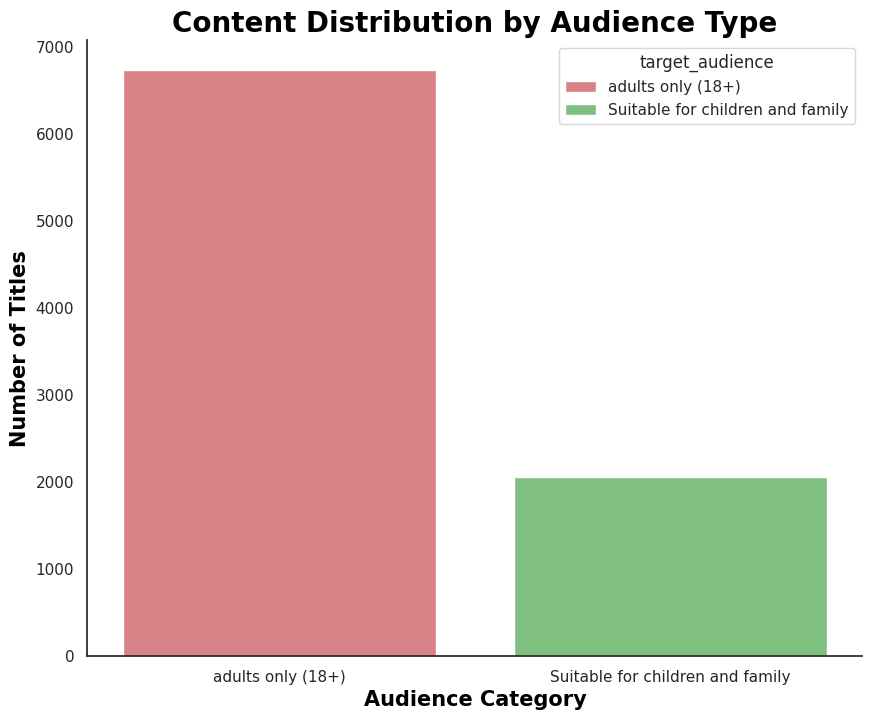

In [10]:
plt.figure(figsize=(10,8))
#custom_palette = ["#FFEB3B", "#00BFFF", "#FF69B4", "#32CD32", "#FFA500"]## لوحة الالوان الخاصه فيني
sns.histplot(data=df, x='target_audience',hue='target_audience' ,palette=['#B20710','green'],shrink=.8 )
plt.title('Content Distribution by Audience Type',fontsize=20, fontweight='bold', color='black')
plt.xlabel('Audience Category',fontsize=15, fontweight='bold',color='black')
plt.ylabel('Number of Titles',fontsize=15, fontweight='bold',color='black')
sns.despine()
plt.show

## DataFarm ##
'''
counts = df['target_audience'].value_counts()
labels = counts.index.tolist()
values = counts.values.tolist()

## 3D انشاء ##
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": "3d"})
plt.style.use('_mpl-gallery')

x = np.array([1, 2]) # موقع العامود الاول والثاني
y = np.array([1, 1]) # على صف واحد
z = np.zeros(2) # قاعدة تبدأ من الصفر

dx = np.ones(2) * 0.5
dy = np.ones(2) * 0.5
dz = values
## Visualize the Data ##
ax.bar3d(x, y, z, dx, dy, dz, color='#B20710', shade=True)
ax.set_xticks(x + 0.3)
ax.set_xticklabels(labels, fontsize=16, fontweight='bold')

ax.xaxis.labelpad = 30

##اخفاء المحاور لبغير ضرورية##
ax.set_yticks([])
#ax.set_zlabel('Number of Titles', fontsize=12, fontweight='bold',labelpad=20)
ax.set_zlabel('Number of Titles', fontsize=7, fontweight='bold')

plt.title('3D View: Content Distribution by Audience', fontsize=16, fontweight='bold')
#labelpad=30
#plt.tight_layout(pad=8)
ax.view_init(elev=25,azim=45)
plt.show()
'''



type
Movie      6126
TV Show    2664
Name: count, dtype: int64
country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


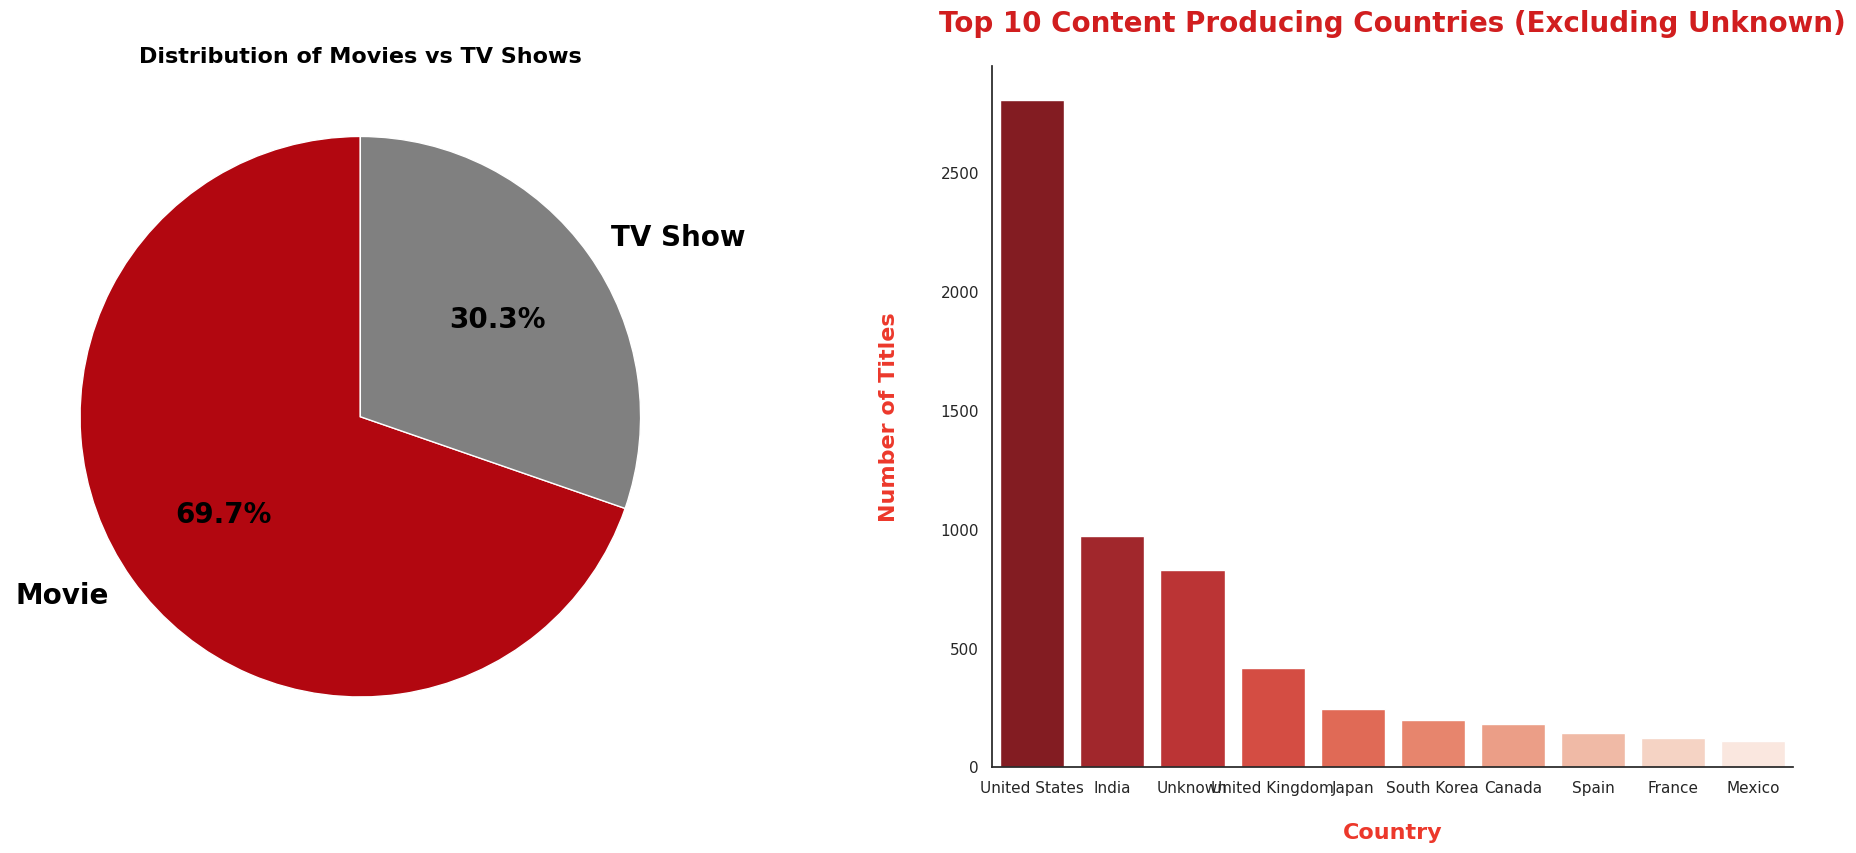

In [11]:
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)

#  هل نتفلكس تنتج مسلسلات اكثر او افلام Q2

type_counts = df['type'].value_counts().head()
print(type_counts)

#  1 Visualize the Data
custom_colors = ['#B20710', '#808080']

plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',startangle=90, colors=custom_colors,
  textprops={'fontsize': 20,'fontweight':'bold', 'color': 'black'})

plt.title('Distribution of Movies vs TV Shows', fontweight='bold',fontsize=16, color='black', pad=1)


##########################################################################################################################
# ?ماهي اكثر الدول انتاجا Q3

plt.subplot(1, 2, 2)

#print(df['country'].unique())
top_10_country = df['country'].value_counts().head(10)
print(top_10_country)

#  2 Visualize the Data
colors = sns.color_palette("Reds_r", n_colors=10)

sns.barplot(x=top_10_country.index, y=top_10_country.values, hue=top_10_country.index, palette=colors)

plt.title('Top 10 Content Producing Countries (Excluding Unknown)',fontsize=20,fontweight='bold',color=colors[2], pad=25,)#fontweight='bold'

plt.xlabel('Country', fontsize=16, fontweight='bold', color=colors[3],labelpad=20)

plt.ylabel('Number of Titles', fontsize=16, fontweight='bold', color=colors[3],labelpad=30)

sns.despine()

plt.tight_layout(pad=5.0)

In [12]:

'''
ax = plt.gca() # الحصول على المحور الحالي
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
for tick_label, color in zip(ax.get_xticklabels(), colors):
    tick_label.set_color(color)
'''

"\nax = plt.gca() # الحصول على المحور الحالي\nplt.xticks(fontsize=12, fontweight='bold')\nplt.yticks(fontsize=12, fontweight='bold')\nfor tick_label, color in zip(ax.get_xticklabels(), colors):\n    tick_label.set_color(color)\n"

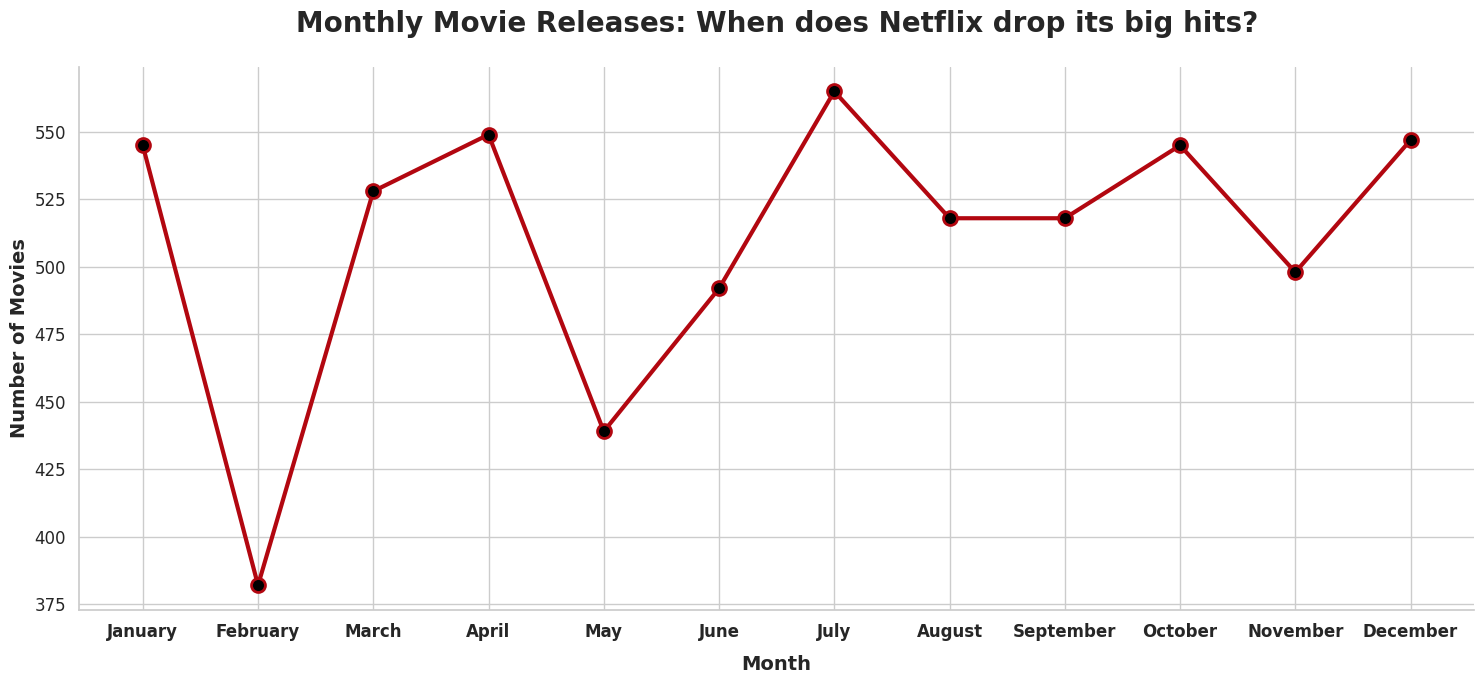

In [13]:
# ماهو موسم تصدير نتفلكس اعمالها Q4
df['date_added'] = df['date_added'].str.strip() # هrun تنظيف المسافات يستخدم  مره واحده
df['date_added'] = pd.to_datetime(df['date_added'])
df['month_added'] = df['date_added'].dt.month_name()

months_order = ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']

monthly_counts = df[df['type'] == 'Movie']['month_added'].value_counts().reindex(months_order)

plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")

plt.plot(monthly_counts.index, monthly_counts.values, color='#B20710', marker='o', linewidth=3, markersize=10, markerfacecolor='black', markeredgewidth=2)

#plt.fill_between(monthly_counts.index, monthly_counts.values, color='#B20710', alpha=0.1)
plt.title('Monthly Movie Releases: When does Netflix drop its big hits?',
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Month', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Number of Movies', fontsize=14, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()
